Filtered sample size: 348
Cook's threshold: 0.010753
Loaded coefficient file with 1000 iterations and 48 features.
Prediction matrix shape: (1000, 348)
Saved:
- observation summary predictions
- observation-level predictions for all iterations
- yearly county-average summary
- area-weighted California yield summary
- area-weighted California yield all-iterations file


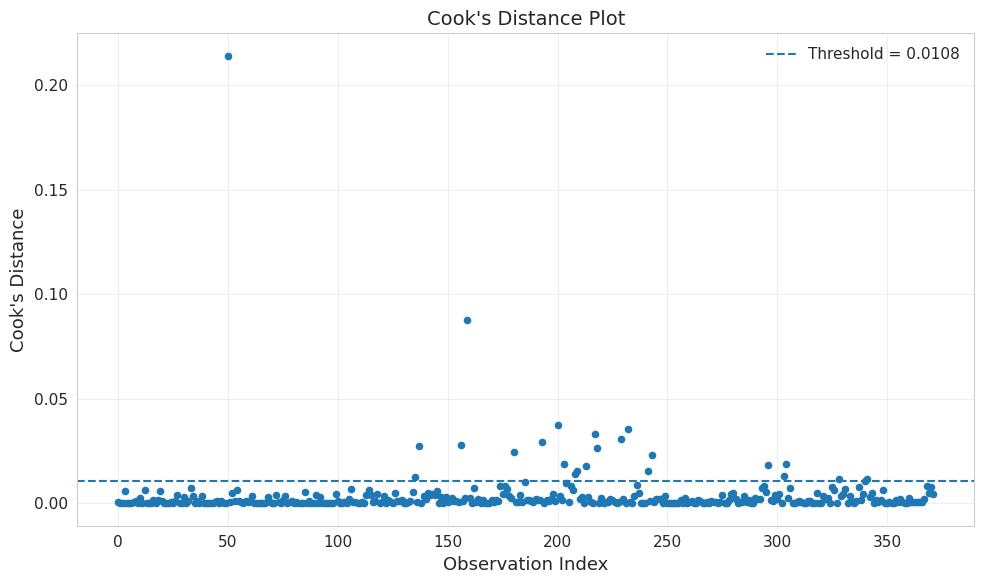

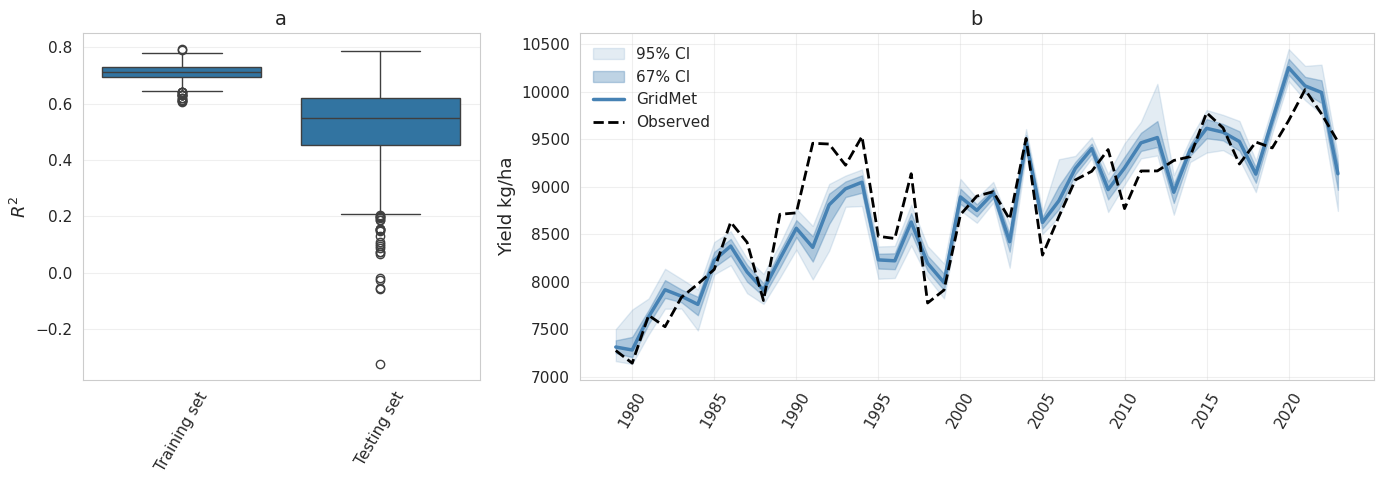

<Figure size 1200x700 with 0 Axes>

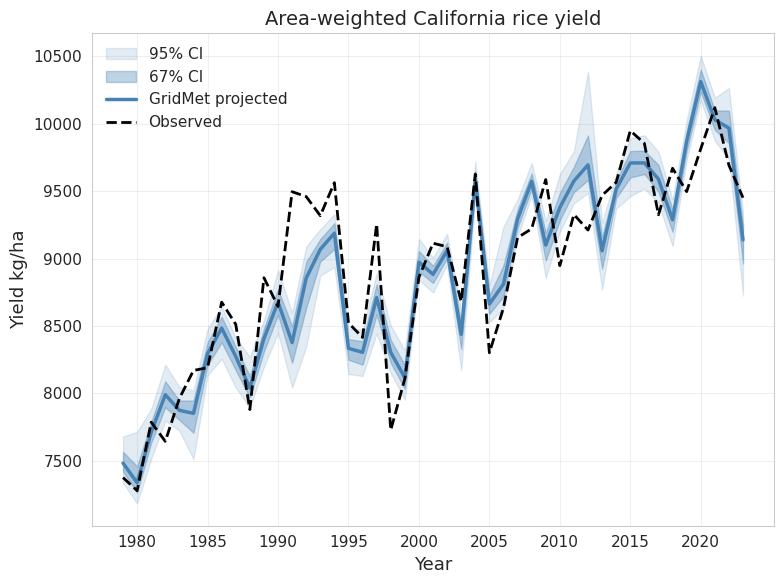

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# =========================================================
# Plot style for publication-quality figures
# =========================================================
sns.set_style("whitegrid")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 15
})

# =========================================================
# File paths
# =========================================================
CLIMATE_DIR = "/group/moniergrp/dbaral"
file_path = os.path.join(CLIMATE_DIR, "run_project/input_data/gridmet_hist_model_input")
save_path = os.path.join(CLIMATE_DIR, "run_project/output_data/historical_model")

coef_file = os.path.join(save_path, "gridmet_lasso_1000_iterations_coefficients_no_intercept.csv")
metrics_file = os.path.join(save_path, "gridmet_lasso_1000_iterations_stability_metrics_no_intercept.csv")

# static county rice area file
area_file = os.path.join(CLIMATE_DIR, "run_project/input_data/rice_area/county_rice_area_static.csv")

plot_save_dir = "/group/moniergrp/dbaral/run_project/output_data/projection/gridmet_hist"

os.makedirs(save_path, exist_ok=True)
os.makedirs(plot_save_dir, exist_ok=True)


# =========================================================
# Helper 1
# Load raw historical data
# =========================================================
def load_raw_data():
    df = pd.read_csv(os.path.join(file_path, "Lasso_Model_Input_Variables_1979_2023_v2.csv"))
    return df


# =========================================================
# Helper 2
# Load static rice area data
# =========================================================
def load_area_data():
    """
    Load static county rice area data.

    Expected columns:
        county
        rice_area_ha
    """
    area_df = pd.read_csv(area_file)

    required_cols = {"county", "rice_area_ha"}
    missing = required_cols - set(area_df.columns)
    if missing:
        raise ValueError(f"Area file is missing required columns: {missing}")

    return area_df


# =========================================================
# Helper 3
# Build design matrix exactly like training
# =========================================================
def build_design_matrix(df):
    df_model = df.copy()

    df_model = df_model[df_model["yield_kg_ha"].notna()].copy()

    cols_exclude = ["county", "year", "yield_kg_ha"]
    climate_cols = [c for c in df_model.columns if c not in cols_exclude]

    climate_center_means = {}
    for col in climate_cols:
        mean_val = df_model[col].mean()
        climate_center_means[col] = float(mean_val)
        df_model[col] = df_model[col] - mean_val

    for col in climate_cols:
        df_model[f"{col}_sq"] = df_model[col] ** 2

    squared_cols = [f"{c}_sq" for c in climate_cols]

    county_dummies = pd.get_dummies(
        df_model["county"],
        prefix="county",
        drop_first=False
    ).astype(int)

    base_year = int(df_model["year"].min())
    time_trend = df_model["year"] - base_year

    county_trends = county_dummies.multiply(time_trend, axis=0)
    county_trends.columns = [c.replace("county", "trend") for c in county_trends.columns]

    X_df = pd.concat(
        [
            df_model[climate_cols + squared_cols],
            county_dummies,
            county_trends
        ],
        axis=1
    )

    Y = df_model["yield_kg_ha"].copy()
    feature_cols_final = list(X_df.columns)

    return (
        df_model,
        X_df,
        Y,
        feature_cols_final,
        climate_cols,
        squared_cols,
        climate_center_means,
        base_year
    )


# =========================================================
# Helper 4
# Apply same Cook's-distance filtering used in training
# =========================================================
def remove_outliers_with_cooks_distance(df_model, X_df, Y):
    X_const = sm.add_constant(X_df)
    model_sm = sm.OLS(Y, X_const).fit()

    influence = model_sm.get_influence()
    cooks_d = influence.cooks_distance[0]

    threshold = 4 / len(Y)
    mask = cooks_d < threshold

    df_filtered = df_model.loc[mask].copy()
    X_filtered = X_df.loc[mask].copy()
    Y_filtered = Y.loc[mask].copy()

    return df_filtered, X_filtered, Y_filtered, cooks_d, threshold, mask


# =========================================================
# Helper 5
# Load coefficient file and reshape to wide matrix
# =========================================================
def load_coefficient_matrix(coef_file, feature_cols_final):
    coef_long = pd.read_csv(coef_file)

    coef_wide = coef_long.pivot(index="iteration", columns="feature", values="coefficient")
    coef_wide = coef_wide.reindex(columns=feature_cols_final)

    missing_cols = coef_wide.columns[coef_wide.isna().all()].tolist()
    if len(missing_cols) > 0:
        raise ValueError(f"Missing feature columns in coefficient file: {missing_cols}")

    return coef_long, coef_wide


# =========================================================
# Helper 6
# Predict historical yield for all 1000 models
# =========================================================
def predict_all_models(X_filtered, coef_wide):
    X_mat = X_filtered.values
    B_mat = coef_wide.values
    pred_matrix = B_mat @ X_mat.T
    return pred_matrix


# =========================================================
# Helper 7
# Build observation-level prediction dataframes
# =========================================================
def build_observation_prediction_df(df_filtered, pred_matrix, coef_wide):
    pred_df = df_filtered[["county", "year", "yield_kg_ha"]].copy().reset_index(drop=True)

    pred_df["pred_median"] = np.median(pred_matrix, axis=0)
    pred_df["pred_mean"] = np.mean(pred_matrix, axis=0)
    pred_df["pred_p2_5"] = np.percentile(pred_matrix, 2.5, axis=0)
    pred_df["pred_p16_5"] = np.percentile(pred_matrix, 16.5, axis=0)
    pred_df["pred_p83_5"] = np.percentile(pred_matrix, 83.5, axis=0)
    pred_df["pred_p97_5"] = np.percentile(pred_matrix, 97.5, axis=0)

    pred_matrix_df = pd.DataFrame(
        pred_matrix.T,
        columns=[f"pred_iter_{i}" for i in coef_wide.index]
    )

    pred_df_all = pd.concat([pred_df, pred_matrix_df], axis=1)

    return pred_df, pred_df_all


# =========================================================
# Helper 8
# Build yearly county-average prediction summary
# =========================================================
def build_yearly_prediction_summary(df_filtered, pred_matrix, coef_wide):
    years = sorted(df_filtered["year"].unique())
    year_index = pd.Index(years, name="year")

    yearly_pred_list = []

    for row_num, iteration in enumerate(coef_wide.index):
        temp_df = df_filtered[["year"]].copy()
        temp_df["predicted_yield"] = pred_matrix[row_num, :]

        yearly_avg = temp_df.groupby("year")["predicted_yield"].mean().reindex(year_index)
        yearly_pred_list.append(yearly_avg.values)

    yearly_pred_matrix = np.vstack(yearly_pred_list)

    observed_yearly = (
        df_filtered.groupby("year")["yield_kg_ha"]
        .mean()
        .reindex(year_index)
    )

    summary_df = pd.DataFrame({
        "year": years,
        "observed_yield": observed_yearly.values,
        "pred_median": np.median(yearly_pred_matrix, axis=0),
        "pred_mean": np.mean(yearly_pred_matrix, axis=0),
        "pred_p2_5": np.percentile(yearly_pred_matrix, 2.5, axis=0),
        "pred_p16_5": np.percentile(yearly_pred_matrix, 16.5, axis=0),
        "pred_p83_5": np.percentile(yearly_pred_matrix, 83.5, axis=0),
        "pred_p97_5": np.percentile(yearly_pred_matrix, 97.5, axis=0),
    })

    return summary_df, yearly_pred_matrix


# =========================================================
# Helper 9
# Calculate area-weighted California rice yield
# using static county rice area
# =========================================================
def calculate_area_weighted_california_yield(pred_obs_all_df, area_df, save_path):
    """
    Calculate area-weighted California rice yield for each historical year
    using static county rice area.

    Formula:
        statewide_yield = sum(yield_county * rice_area_ha_county) / sum(rice_area_ha_county)

    pred_obs_all_df must contain:
        county, year, yield_kg_ha, pred_iter_*

    area_df must contain:
        county, rice_area_ha
    """

    # merge by county only because area is static
    merged_df = pred_obs_all_df.merge(
        area_df,
        on="county",
        how="left"
    )

    if merged_df["rice_area_ha"].isna().any():
        missing_counties = merged_df.loc[merged_df["rice_area_ha"].isna(), "county"].drop_duplicates().tolist()
        raise ValueError(
            "Some counties are missing rice_area_ha after merging.\n"
            f"Missing counties: {missing_counties[:10]}"
        )

    pred_cols = [c for c in merged_df.columns if c.startswith("pred_iter_")]

    # observed statewide area-weighted yield
    observed_aw = (
        merged_df.assign(weighted_obs=merged_df["yield_kg_ha"] * merged_df["rice_area_ha"])
        .groupby("year")
        .agg(
            observed_weighted_sum=("weighted_obs", "sum"),
            total_area=("rice_area_ha", "sum")
        )
        .reset_index()
    )

    observed_aw["observed_ca_yield_area_weighted"] = (
        observed_aw["observed_weighted_sum"] / observed_aw["total_area"]
    )

    observed_aw = observed_aw[["year", "observed_ca_yield_area_weighted"]]

    # projected statewide area-weighted yield for each iteration and year
    years = sorted(merged_df["year"].unique())
    proj_yearly_records = []

    for year in years:
        year_df = merged_df[merged_df["year"] == year].copy()
        total_area = year_df["rice_area_ha"].sum()

        record = {"year": year}

        for pred_col in pred_cols:
            weighted_yield = (year_df[pred_col] * year_df["rice_area_ha"]).sum() / total_area
            record[pred_col] = weighted_yield

        proj_yearly_records.append(record)

    proj_yearly_df = pd.DataFrame(proj_yearly_records)

    california_area_weighted_df = pd.DataFrame({
        "year": proj_yearly_df["year"],
        "projected_ca_yield_area_weighted_median": proj_yearly_df[pred_cols].median(axis=1),
        "projected_ca_yield_area_weighted_mean": proj_yearly_df[pred_cols].mean(axis=1),
        "projected_ca_yield_area_weighted_p2_5": proj_yearly_df[pred_cols].quantile(0.025, axis=1),
        "projected_ca_yield_area_weighted_p16_5": proj_yearly_df[pred_cols].quantile(0.165, axis=1),
        "projected_ca_yield_area_weighted_p83_5": proj_yearly_df[pred_cols].quantile(0.835, axis=1),
        "projected_ca_yield_area_weighted_p97_5": proj_yearly_df[pred_cols].quantile(0.975, axis=1),
    })

    california_area_weighted_df = observed_aw.merge(
        california_area_weighted_df,
        on="year",
        how="left"
    )

    california_area_weighted_df.to_csv(
        os.path.join(save_path, "california_historical_area_weighted_yield_from_gridmet_1000_models.csv"),
        index=False
    )

    proj_yearly_df.to_csv(
        os.path.join(save_path, "california_historical_area_weighted_yield_all_iterations.csv"),
        index=False
    )

    return california_area_weighted_df, proj_yearly_df


# =========================================================
# Plot 1
# Train vs test R2 boxplot
# =========================================================
def plot_r2_boxplot(metrics_df, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 6))

    r2_long = metrics_df.melt(
        id_vars="iteration",
        value_vars=["R2_train", "R2_test"],
        var_name="set_type",
        value_name="R2"
    )

    r2_long["set_type"] = r2_long["set_type"].replace({
        "R2_train": "Training set",
        "R2_test": "Testing set"
    })

    sns.boxplot(data=r2_long, x="set_type", y="R2", ax=ax)
    ax.set_title("a")
    ax.set_xlabel("")
    ax.set_ylabel(r"$R^2$")
    ax.tick_params(axis="x", rotation=60)
    ax.grid(True, axis="y", alpha=0.3)


# =========================================================
# Plot 2
# Historical observed vs predicted yearly yield
# =========================================================
def plot_historical_prediction(summary_df, ax=None, pred_label="GridMet"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    x = summary_df["year"].values

    ax.fill_between(
        x,
        summary_df["pred_p2_5"].values,
        summary_df["pred_p97_5"].values,
        color="steelblue",
        alpha=0.15,
        label="95% CI"
    )

    ax.fill_between(
        x,
        summary_df["pred_p16_5"].values,
        summary_df["pred_p83_5"].values,
        color="steelblue",
        alpha=0.35,
        label="67% CI"
    )

    ax.plot(
        x,
        summary_df["pred_median"].values,
        color="steelblue",
        linewidth=2.5,
        label=pred_label
    )

    ax.plot(
        x,
        summary_df["observed_yield"].values,
        color="black",
        linewidth=2,
        linestyle="--",
        label="Observed"
    )

    ax.set_title("b")
    ax.set_xlabel("")
    ax.set_ylabel("Yield kg/ha")
    ax.set_xticks(np.arange(1980, 2025, 5))
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=60)
    ax.legend(frameon=False, loc="best")


# =========================================================
# Plot 3
# Area-weighted California yield
# =========================================================
def plot_area_weighted_california_yield(california_aw_df, ax=None, pred_label="GridMet projected"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    x = california_aw_df["year"].values

    ax.fill_between(
        x,
        california_aw_df["projected_ca_yield_area_weighted_p2_5"].values,
        california_aw_df["projected_ca_yield_area_weighted_p97_5"].values,
        color="steelblue",
        alpha=0.15,
        label="95% CI"
    )

    ax.fill_between(
        x,
        california_aw_df["projected_ca_yield_area_weighted_p16_5"].values,
        california_aw_df["projected_ca_yield_area_weighted_p83_5"].values,
        color="steelblue",
        alpha=0.35,
        label="67% CI"
    )

    ax.plot(
        x,
        california_aw_df["projected_ca_yield_area_weighted_median"].values,
        color="steelblue",
        linewidth=2.5,
        label=pred_label
    )

    ax.plot(
        x,
        california_aw_df["observed_ca_yield_area_weighted"].values,
        color="black",
        linewidth=2,
        linestyle="--",
        label="Observed"
    )

    ax.set_title("Area-weighted California rice yield")
    ax.set_xlabel("Year")
    ax.set_ylabel("Yield kg/ha")
    ax.set_xticks(np.arange(1980, 2025, 5))
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, loc="best")


# =========================================================
# Plot 4
# Cook's distance
# =========================================================
def plot_cooks_distance(cooks_d, threshold):
    plt.figure(figsize=(10, 6))
    plt.scatter(np.arange(len(cooks_d)), cooks_d, s=20)
    plt.axhline(threshold, linestyle="--", label=f"Threshold = {threshold:.4f}")
    plt.title("Cook's Distance Plot")
    plt.xlabel("Observation Index")
    plt.ylabel("Cook's Distance")
    plt.legend(frameon=False, loc="best")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()


# =========================================================
# Main workflow
# =========================================================
df = load_raw_data()
area_df = load_area_data()

(
    df_model,
    X_df,
    Y,
    feature_cols_final,
    climate_cols,
    squared_cols,
    climate_center_means,
    base_year
) = build_design_matrix(df)

df_filtered, X_filtered, Y_filtered, cooks_d, cooks_threshold, cooks_mask = remove_outliers_with_cooks_distance(
    df_model,
    X_df,
    Y
)

print(f"Filtered sample size: {len(df_filtered)}")
print(f"Cook's threshold: {cooks_threshold:.6f}")

coef_long, coef_wide = load_coefficient_matrix(coef_file, feature_cols_final)
print(f"Loaded coefficient file with {coef_wide.shape[0]} iterations and {coef_wide.shape[1]} features.")

pred_matrix = predict_all_models(X_filtered, coef_wide)
print("Prediction matrix shape:", pred_matrix.shape)

pred_obs_summary_df, pred_obs_all_df = build_observation_prediction_df(
    df_filtered,
    pred_matrix,
    coef_wide
)

yearly_summary_df, yearly_pred_matrix = build_yearly_prediction_summary(
    df_filtered,
    pred_matrix,
    coef_wide
)

california_area_weighted_df, california_area_weighted_all_iter_df = calculate_area_weighted_california_yield(
    pred_obs_all_df=pred_obs_all_df,
    area_df=area_df,
    save_path=save_path
)

pred_obs_summary_df.to_csv(
    os.path.join(save_path, "gridmet_predictions_1000_models_observation_summary.csv"),
    index=False
)

pred_obs_all_df.to_csv(
    os.path.join(save_path, "gridmet_predictions_1000_models_all_iterations.csv"),
    index=False
)

yearly_summary_df.to_csv(
    os.path.join(save_path, "gridmet_predictions_1000_models_yearly_summary.csv"),
    index=False
)

print("Saved:")
print("- observation summary predictions")
print("- observation-level predictions for all iterations")
print("- yearly county-average summary")
print("- area-weighted California yield summary")
print("- area-weighted California yield all-iterations file")

metrics_df = pd.read_csv(metrics_file)

plot_cooks_distance(cooks_d, cooks_threshold)
plt.savefig(
    os.path.join(plot_save_dir, "cooks_distance_plot.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(plot_save_dir, "cooks_distance_plot.pdf"),
    bbox_inches="tight"
)
plt.show()
plt.close()

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [1, 2]}
)

plot_r2_boxplot(metrics_df, ax=axes[0])
plot_historical_prediction(yearly_summary_df, ax=axes[1], pred_label="GridMet")

plt.tight_layout()

plt.savefig(
    os.path.join(plot_save_dir, "model_performance_and_historical_prediction.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(plot_save_dir, "model_performance_and_historical_prediction.pdf"),
    bbox_inches="tight"
)

plt.show()
plt.close()

plt.figure(figsize=(12, 7))
plot_area_weighted_california_yield(california_area_weighted_df)
plt.tight_layout()

plt.savefig(
    os.path.join(plot_save_dir, "california_area_weighted_yield_historical.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(plot_save_dir, "california_area_weighted_yield_historical.pdf"),
    bbox_inches="tight"
)

plt.show()
plt.close()